## MSA29HCM - Natural Language Processing - Final Project

### Demo: Simple RAG application using different Vector Space Models

#### Group Information

1. Hồ Nhật Thanh - 25MSA23226
2. Bùi Nguyễn Trúc Như - 25MSA23250
3. Nguyễn Văn Nhật - 25MSA23239

### I. Project Overview

#### 1. Introduction and Objectives
The primary objective of this project is to implement, evaluate, and critically compare three distinct classes of Vector Space Models (VSM)—Sparse, Dense, and Contextual models—within a RAG framework for advanced information extraction tasks. By deconstructing the processing pipelines of each model, this project aims to demonstrate a profound mastery of modern retrieval architectures.

#### 2. Model Architectures and Processing Pipelines
To thoroughly understand and master the retrieval process, this project orchestrates three distinct processing pipelines acting upon a unified, domain-specific corpus (an NLP technical document).

* **Phase 1: Data Ingestion and Chunking**

  The raw document is parsed, cleaned, and systematically divided into manageable text chunks using a sliding window approach (e.g., fixed token length with overlap) to ensure that localized context is preserved across boundaries.

* **Phase 2: Sparse Model Pipeline (Lexical Retrieval - BM25)**
  
  This pipeline represents traditional keyword-based search.

  * *Processing*: The corpus undergoes tokenization and normalization. The system builds an Inverted Index, mapping discrete vocabulary terms to their corresponding chunk IDs.

  * *Retrieval*: Upon receiving a query, the model calculates the Okapi BM25 score based on exact term frequency (TF) and inverse document frequency (IDF). It excels at exact-match lookups but is theoretically blind to semantic meaning.

* **Phase 3: Dense Model Pipeline (Semantic Retrieval - Bi-Encoder)**

  This pipeline addresses the vocabulary mismatch problem using deep learning.

  * *Processing*: Both the document chunks and the incoming query are passed independently through a Transformer-based Bi-Encoder (e.g., Sentence-BERT). The text is compressed into high-dimensional, dense floating-point vectors representing latent semantic meaning.

  * *Retrieval*: The system computes the Cosine Similarity between the query vector and all chunk vectors in the multidimensional space, enabling the retrieval of synonymous and conceptually related information.

* **Phase 4: Context Model Pipeline (Single-Stage Cross-Encoder)**
  
  This pipeline serves as the ultimate semantic precision baseline. Unlike industry-standard implementations that use a filtering step, this project intentionally deploys a "naive" or single-stage Cross-Encoder approach to empirically demonstrate both the absolute ceiling of retrieval accuracy and the severe computational limitations of deep learning inference.
  
  * *Processing*: No pre-computation or initial filtering is performed. Upon receiving a query, the system dynamically pairs the query with every single chunk present in the entire document corpus
  
  * *Retrieval*: The Cross-Encoder concatenates the user query and each individual chunk into a single, unified sequence (e.g., [CLS] Query [SEP] Chunk [SEP]). The Transformer's self-attention mechanism performs exhaustive token-level cross-comparisons across the entire dataset, calculating an absolute relevance score for every chunk to extract the definitive Top-K results
  
  * *Architectural Conclusion*: While this pure approach guarantees maximum precision by avoiding the information-loss bottleneck of Dense vectors, it is deliberately implemented to expose the catastrophic latency caused by the $O(L^2)$ time complexity of Transformers. By documenting this extreme execution time, the project mathematically proves the absolute necessity of adopting Two-Stage Retrieval architectures for real-time production systems.

#### **The Computational Imperative of Two-Stage Retrieval**

While the Cross-Encoder provides unparalleled semantic accuracy, applying it directly to an entire database (a Single-Stage approach) is mathematically and computationally unfeasible in production environments.

The core bottleneck lies in the Transformer architecture's self-attention mechanism, which possesses a quadratic time complexity of $O(L^2)$, where $L$ is the combined sequence length of the query and the chunk. Because the query and chunk must be processed simultaneously, Cross-Encoders cannot pre-compute and store document vectors in a database. Evaluating a single query against a modest corpus of 100,000 document chunks would require 100,000 distinct neural network inference passes at runtime, resulting in catastrophic latency (often taking minutes per query).

Therefore, implementing a Two-Stage Retrieval architecture is not merely an optimization, but a strict architectural requirement to balance speed and accuracy:
1. **Stage 1 (High Recall - Asymptotic Speed):**
The system utilizes the Dense or Sparse models (which operate on pre-computed Inverted Indexes or Approximate Nearest Neighbor graphs) to scan millions of records in milliseconds, filtering the corpus down to a small candidate pool (e.g., Top 50 chunks).
2. **Stage 2 (High Precision - Deep Inference):**
The Cross-Encoder acts strictly as a Re-ranker. It executes its computationally expensive cross-attention mechanism only on the 50 candidates retrieved in Stage 1.

This hybrid approach effectively resolves the $O(L^2)$ bottleneck, allowing the RAG system to deliver deep analytical accuracy while strictly adhering to enterprise latency constraints.

#### 3. Testing Methodology
To empirically validate the theoretical behaviors of these models, a simple software testing framework is established. A curated "Ground Truth" dataset comprising varied test scenarios is executed across all three pipelines. The test cases are strategically categorized to expose the strengths and weaknesses of each architecture:

* **Exact Keyword Queries**: To test Sparse model precision.
* **Synonym and Semantic Queries**: To evaluate the Dense model's linguistic mapping.
* **Complex Contextual Traps**: To challenge Bi-Encoders and prove the necessity of Cross-Encoders.
* **Typo Robustness**: To test tokenizer resilience against malformed inputs.
* **Out-of-Domain Queries**: To verify the system's ability to reject irrelevant information.

#### 4. Comparative Evaluation and Conclusions
The final phase of the project involves a quantitative and qualitative analysis of the test results.

* **Quantitative Metrics**: The performance of each model group is benchmarked using standard statistical retrieval metrics, primarily Mean Reciprocal Rank (MRR), to objectively measure ranking accuracy.

* **Architectural Assessment**: The project will analyze the trade-offs between computational latency, memory footprint, and retrieval precision.

### II. Source code

#### 2.1. Data Ingestion and Chunking

- Load sample data

In [ ]:
!pip install pypdf 

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import data_ingest
import json

In [8]:
data_path = 'data/NLP_Architecture-of-meaning.pdf'
raw_text = ''

try:
    print("Reading PDF file...")
    raw_text = data_ingest.extract_text_from_pdf(data_path)
    print(f"-> Extraction successful. Text length: {len(raw_text)} characters ({len(raw_text.split())} words).") 
except Exception as e:
    print(f"An error occurred: {e}")

Reading PDF file...
-> Extraction successful. Text length: 28038 characters (3264 words).


In [9]:
try:
    # Step 2: Chunking (e.g., chunk_size=150 words, overlap=30 words)
    print("\nPerforming chunking...")
    chunks = data_ingest.sliding_window_chunking(raw_text, chunk_size=150, chunk_overlap=30)
    print(f"-> Split into {len(chunks)} chunks.")
    
    # Demo: print the first 2 chunks
    print("\n--- DEMO FIRST 2 CHUNKS ---")
    for idx, chunk in enumerate(chunks[:2]):
        print(f"\n[Chunk {idx + 1}] (Length: {len(chunk.split())} words):")
        print("-" * 50)
        print(chunk)
        print("-" * 50)
except Exception as e:
    print(f"An error occurred: {e}")


Performing chunking...
-> Split into 27 chunks.

--- DEMO FIRST 2 CHUNKS ---

[Chunk 1] (Length: 150 words):
--------------------------------------------------
ARCHITECTURES OF MEANING: A COMPREHENSIVE ANALYSIS OF VECTOR SPACE MODELS AND DEEP INFORMATION RETRIEVAL IN NATURAL LANGUAGE PROCESSING ABSTRACT The exponential growth of unstructured textual data in the digital era has necessitated advanced computational methods for information extraction and retrieval. Natural Language Processing (NLP) has evolved from rudimentary rule-based systems to highly complex, billion-parameter neural architectures. However, the generative capabilities of Large Language Models (LLMs) are fundamentally constrained by their inability to reliably access real-time, domain-specific, and factual knowledge, often resulting in hallucinations. To mitigate this, the Retrieval-Augmented Generation (RAG) framework has emerged as the industry standard. The efficacy of a RAG pipeline is inextricably linked to its u

In [18]:
eval_df_path = 'data/eval_dataset.json'

# Load the verified evaluation dataset
with open(eval_df_path, "r", encoding="utf-8") as f:
    eval_dataset = json.load(f)
print(f"Loaded {len(eval_dataset)} test cases successfully!")

Loaded 20 test cases successfully!


#### 2.2. Sparse Model Pipeline

In [20]:
import math
import string
import time
from collections import Counter

def simple_tokenizer(text):
    """
    Tokenize and normalize text by converting to lowercase and removing punctuation.
    """
    text = text.lower()
    # Remove punctuation using translate table
    text = text.translate(str.maketrans("", "", string.punctuation))
    return text.split()


class CustomBM25:
    def __init__(self, corpus, k1=1.5, b=0.75):
        """
        Initialize BM25 index with a corpus of chunks.
        
        Args:
            corpus (list of str): List of document chunks.
            k1 (float): Term frequency saturation tuning parameter (default: 1.5).
            b (float): Document length normalization tuning parameter (default: 0.75).
        """
        self.k1 = k1
        self.b = b
        self.corpus_size = len(corpus)
        
        # Step 1: Tokenization & Normalization
        self.tokenized_corpus = [simple_tokenizer(doc) for doc in corpus]
        
        # Step 2: Calculate document lengths and average document length (avgdl)
        self.doc_lens = [len(doc) for doc in self.tokenized_corpus]
        self.avgdl = sum(self.doc_lens) / self.corpus_size if self.corpus_size > 0 else 0
        
        # Step 3: Compute Term Frequencies (TF) for each document
        self.doc_term_freqs = [Counter(doc) for doc in self.tokenized_corpus]
        
        # Step 4: Build the Inverted Index (term -> list of doc_ids)
        self.inverted_index = {}
        self.df = Counter()  # Document Frequency
        
        for doc_idx, doc in enumerate(self.tokenized_corpus):
            unique_terms = set(doc)
            for term in unique_terms:
                self.df[term] += 1
                if term not in self.inverted_index:
                    self.inverted_index[term] = []
                self.inverted_index[term].append(doc_idx)
                
        # Step 5: Pre-compute Inverse Document Frequency (IDF) using standard Okapi formula
        self.idf = {}
        for term, freq in self.df.items():
            # Standard Okapi BM25 IDF formula
            self.idf[term] = math.log(1 + (self.corpus_size - freq + 0.5) / (freq + 0.5))

    def get_bm25_score(self, query_terms, doc_idx):
        """
        Calculate the Okapi BM25 score for a tokenized query against a specific document.
        """
        score = 0.0
        doc_len = self.doc_lens[doc_idx]
        tf_counter = self.doc_term_freqs[doc_idx]
        
        for term in query_terms:
            if term not in self.idf:
                continue
            
            tf = tf_counter[term]
            idf = self.idf[term]
            
            # Okapi BM25 formula for TF saturation and length normalization
            numerator = tf * (self.k1 + 1)
            denominator = tf + self.k1 * (1 - self.b + self.b * (doc_len / self.avgdl))
            score += idf * (numerator / denominator)
            
        return score

    def retrieve(self, query, corpus, top_k=5):
        """
        Retrieve the top-K chunks relevant to the query.
        
        Returns:
            list of dict: Sorted top-K matches with original indices, scores, and text.
            float: Time taken in seconds.
        """
        start_time = time.time()
        
        # 1. Tokenize query
        query_terms = simple_tokenizer(query)
        
        # 2. Find candidate documents using the Inverted Index (avoid scanning all chunks if score is 0)
        candidate_doc_ids = set()
        for term in query_terms:
            if term in self.inverted_index:
                candidate_doc_ids.update(self.inverted_index[term])
                
        # 3. Calculate scores for candidate documents only
        results = []
        for doc_idx in candidate_doc_ids:
            score = self.get_bm25_score(query_terms, doc_idx)
            results.append({
                "chunk_index": doc_idx,
                "chunk_text": corpus[doc_idx],
                "score": float(score)
            })
            
        # 4. Sort in descending order
        sorted_results = sorted(results, key=lambda x: x["score"], reverse=True)
        
        execution_time = time.time() - start_time
        return sorted_results[:top_k], execution_time


# --- THỰC THI THỬ NGHIỆM ---
try:
    print("=== Phase 2: Sparse Model (BM25) Processing ===")
    
    # 1. Khởi tạo và Indexing corpus chunks (biến 'chunks' lấy từ Phase 1)
    bm25_index = CustomBM25(chunks)
    print(f"Indexing completed. Vocabulary size: {len(bm25_index.inverted_index)} unique terms.")
    
    # 2. Test thử một câu truy vấn mẫu bằng BM25
    test_query = "What is the formula for Okapi BM25 ranking algorithm?"
    top_results, duration = bm25_index.retrieve(test_query, chunks, top_k=3)
    
    # 3. Hiển thị kết quả
    print(f"\nInference completed in {duration:.4f} seconds.")
    print(f"Query: '{test_query}'\n")
    print("--- Top BM25 Retrieval Results ---")
    for rank, res in enumerate(top_results):
        print(f"Rank {rank + 1} (Score: {res['score']:.4f}) | Chunk Index: {res['chunk_index']}")
        print(f"Text: {res['chunk_text']}\n")
        
except NameError:
    print("Lỗi: Hãy chắc chắn rằng bạn đã chạy các cell Phase 1 phía trên để nạp biến 'chunks' vào bộ nhớ.")
except Exception as e:
    print(f"Đã xảy ra lỗi: {e}")


=== Phase 2: Sparse Model (BM25) Processing ===
Indexing completed. Vocabulary size: 1189 unique terms.

Inference completed in 0.0001 seconds.
Query: 'What is the formula for Okapi BM25 ranking algorithm?'

--- Top BM25 Retrieval Results ---
Rank 1 (Score: 11.5047) | Chunk Index: 9
Text: the corpus (IDF). The weight of term i in document j is calculated as: Where: ● N is the total number of documents in the collection. ● is the document frequency (the number of documents containing term i ). 3.2 The Okapi BM25 Ranking Algorithm While TF-IDF is highly educational, production-grade search engines (such as Elasticsearch, Apache Solr, and OpenSearch) implement a more advanced probabilistic model known as BM25 (Best Matching 25). BM25 improves upon TF-IDF in two critical ways. First, it introduces Term Frequency Saturation . In TF-IDF, if a word appears 100 times, its TF score scales linearly. BM25 recognizes that a word appearing 10 times is more relevant than 1 time, but a word appearing

#### 2.3. Dense Model Pipeline

In [21]:
import time
from sentence_transformers import SentenceTransformer, util

class DenseRetriever:
    def __init__(self, model_name="sentence-transformers/all-MiniLM-L6-v2"):
        """
        Initialize and load the pre-trained Bi-Encoder model.
        We use 'all-MiniLM-L6-v2' which is fast, lightweight, and generates 384-dimensional embeddings.
        """
        # Load the model (avoid reloading if already instantiated)
        print(f"Loading Bi-Encoder model: '{model_name}'...")
        self.model = SentenceTransformer(model_name)
        self.chunk_embeddings = None
        print("Model loaded successfully.")
        
    def index_corpus(self, chunks):
        """
        Offline Phase: Pre-compute and store embeddings for all chunks in the corpus.
        """
        start_time = time.time()
        print(f"Encoding {len(chunks)} document chunks into dense vectors...")
        
        # Pre-compute embeddings (we convert to PyTorch tensors for fast matrix operations)
        self.chunk_embeddings = self.model.encode(chunks, convert_to_tensor=True)
        
        duration = time.time() - start_time
        print(f"-> Indexing completed in {duration:.4f} seconds.")
        print(f"-> Embedding space shape: {list(self.chunk_embeddings.shape)} (Chunks x Dimensions)")
        
    def retrieve(self, query, corpus, top_k=5):
        """
        Online Phase: Embed the query at runtime and compute Cosine Similarity against indexed chunks.
        """
        if self.chunk_embeddings is None:
            raise ValueError("Corpus has not been indexed. Please run index_corpus(chunks) first.")
            
        start_time = time.time()
        
        # 1. Generate dense vector for the query
        query_embedding = self.model.encode(query, convert_to_tensor=True)
        
        # 2. Compute Cosine Similarity between the query vector and all stored chunk vectors
        # util.cos_sim performs efficient GPU/CPU matrix multiplication
        cos_scores = util.cos_sim(query_embedding, self.chunk_embeddings)[0]
        
        # 3. Package results
        results = []
        for idx, score in enumerate(cos_scores):
            results.append({
                "chunk_index": idx,
                "chunk_text": corpus[idx],
                "score": float(score)
            })
            
        # 4. Sort by Cosine Similarity score in descending order
        sorted_results = sorted(results, key=lambda x: x["score"], reverse=True)
        
        execution_time = time.time() - start_time
        return sorted_results[:top_k], execution_time


# --- THỰC THI THỬ NGHIỆM ---
try:
    print("=== Phase 3: Dense Model (Bi-Encoder) Processing ===")
    
    # 1. Khởi tạo retriever (chỉ load mô hình 1 lần)
    if 'dense_retriever' not in locals():
        dense_retriever = DenseRetriever("sentence-transformers/all-MiniLM-L6-v2")
    
    # 2. Offline indexing: Tính toán trước vector cho toàn bộ chunks (lấy biến 'chunks' từ Phase 1)
    dense_retriever.index_corpus(chunks)
    
    # 3. Online retrieval: Chạy truy vấn ngữ nghĩa
    test_query = "How do deep learning architectures represent text meaning in vector space?"
    top_results, duration = dense_retriever.retrieve(test_query, chunks, top_k=3)
    
    # 4. Hiển thị kết quả
    print(f"\nInference completed in {duration:.4f} seconds.")
    print(f"Query: '{test_query}'\n")
    print("--- Top Dense Retrieval Results (Cosine Similarity) ---")
    for rank, res in enumerate(top_results):
        print(f"Rank {rank + 1} (Score: {res['score']:.4f}) | Chunk Index: {res['chunk_index']}")
        print(f"Text: {res['chunk_text']}\n")
        
except NameError:
    print("Lỗi: Hãy chắc chắn rằng bạn đã chạy các cell Phase 1 phía trên để nạp biến 'chunks' vào bộ nhớ.")
except Exception as e:
    print(f"Đã xảy ra lỗi: {e}")


=== Phase 3: Dense Model (Bi-Encoder) Processing ===
Loading Bi-Encoder model: 'sentence-transformers/all-MiniLM-L6-v2'...


e:\GitHub\machine-learning-exercises\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\thanh\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Fallin

Model loaded successfully.
Encoding 27 document chunks into dense vectors...
-> Indexing completed in 0.3667 seconds.
-> Embedding space shape: [27, 384] (Chunks x Dimensions)

Inference completed in 0.0085 seconds.
Query: 'How do deep learning architectures represent text meaning in vector space?'

--- Top Dense Retrieval Results (Cosine Similarity) ---
Rank 1 (Score: 0.5796) | Chunk Index: 0
Text: ARCHITECTURES OF MEANING: A COMPREHENSIVE ANALYSIS OF VECTOR SPACE MODELS AND DEEP INFORMATION RETRIEVAL IN NATURAL LANGUAGE PROCESSING ABSTRACT The exponential growth of unstructured textual data in the digital era has necessitated advanced computational methods for information extraction and retrieval. Natural Language Processing (NLP) has evolved from rudimentary rule-based systems to highly complex, billion-parameter neural architectures. However, the generative capabilities of Large Language Models (LLMs) are fundamentally constrained by their inability to reliably access real-time, do

#### 2.4. Context Model Pipeline - Cross-Encoder

In [10]:
!pip install sentence-transformers

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/588.9 kB ? eta -:--:--
   ---------------------------------------- 588.9/588.9 kB 607.4 MB/s  0:00:00
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.2 MB 6.0 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.2 MB 6.4 MB/s eta 0:00:01
   ----------------- ---------------------- 3.7/8.2 MB 6.6 MB/s eta 0:00:01
   --------------------- ------------------ 4.5/8.2 MB 5.8 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.2 MB 5.3 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.2 MB 4.7 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.2 MB 4.3 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.2 MB 4.0 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.2 MB 3.8 MB/s eta 0:00:01
   ---------------------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import time
from sentence_transformers import CrossEncoder

def initialize_cross_encoder(model_name="cross-encoder/ms-marco-MiniLM-L-6-v2"):
    """
    Initialize and load a pre-trained Cross-Encoder model.
    """
    print(f"Loading Cross-Encoder model: '{model_name}'...")
    # The model will be downloaded automatically if not already cached
    model = CrossEncoder(model_name)
    print("Model loaded successfully.")
    return model


def single_stage_cross_encoder_retrieval(query, chunks, model, top_k=5):
    """
    Perform single-stage retrieval by pairing the query with ALL chunks
    and predicting relevance scores using the Cross-Encoder.
    
    Args:
        query (str): The search query.
        chunks (list of str): All document chunks in the corpus.
        model (CrossEncoder): The loaded CrossEncoder model.
        top_k (int): Number of top results to return.
        
    Returns:
        list of dict: Top-K chunks with their scores, original indices, and text.
        float: Time taken in seconds.
    """
    start_time = time.time()
    
    # 1. Dynamically pair the query with EVERY single chunk in the entire corpus
    # Format required by Cross-Encoder: [[query, chunk_1], [query, chunk_2], ...]
    pairs = [[query, chunk] for chunk in chunks]
    
    # 2. Compute absolute relevance scores using the self-attention mechanism
    print(f"Evaluating query against {len(chunks)} chunks using Cross-Encoder...")
    scores = model.predict(pairs)
    
    # 3. Package results with their original indices and scores
    results = []
    for idx, (chunk, score) in enumerate(zip(chunks, scores)):
        results.append({
            "chunk_index": idx,
            "chunk_text": chunk,
            "score": float(score)
        })
        
    # 4. Sort the results by score in descending order
    sorted_results = sorted(results, key=lambda x: x["score"], reverse=True)
    
    execution_time = time.time() - start_time
    
    return sorted_results[:top_k], execution_time


e:\GitHub\machine-learning-exercises\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
import pandas as pd
from IPython.display import display

# Khởi tạo mô hình ở chế độ bảo vệ (tránh nạp lại)
if 'ce_model' not in locals():
    ce_model = initialize_cross_encoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

test_results = []

for q in eval_dataset:
    try:
        # Chạy Single-Stage Cross-Encoder
        top_results, duration = single_stage_cross_encoder_retrieval(
            query=q['query'], 
            chunks=chunks, 
            model=ce_model, 
            top_k=3
        )
        
        # Lưu kết quả Top-1 để so sánh nhanh
        if top_results:
            best = top_results[0]
            test_results.append({
                "ID": q['id'],
                "Category": q['category'],
                "Query": q['query'],
                "Best Chunk Index": best['chunk_index'],
                "Score": round(best['score'], 4),
                "Latency (s)": round(duration, 4),
                "Best Snippet": best['chunk_text'][:120] + "..."
            })
            
    except Exception as e:
        print(f"Error executing {q['id']}: {e}")

# Chuyển đổi sang DataFrame để hiển thị đẹp mắt trong Jupyter
df_results = pd.DataFrame(test_results)
display(df_results)


Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating que

,ID,Category,Query,Best Chunk Index,Score,Latency (s),Best Snippet
0,TC01,Exact Keyword,What is the formula for Okapi BM25 ranking alg...,9,5.9729,0.2683,the corpus (IDF). The weight of term i in docu...
1,TC02,Exact Keyword,What does the variable N represent in the TF-I...,9,2.6721,0.0324,the corpus (IDF). The weight of term i in docu...
2,TC03,Exact Keyword,Which algorithm utilizes HNSW for approximate ...,15,8.1206,0.0308,"repair a motor,"" despite having no common word..."
3,TC04,Exact Keyword,What is the specific context window limit for ...,19,2.6916,0.0334,only these 50-100 candidates. It performs the ...
4,TC05,Synonyms,How do modern systems fix the issue when users...,11,-2.0848,0.0311,linearly across millions of documents is compu...
5,TC06,Synonyms,What is the mathematical approach used to meas...,6,-3.2435,0.0310,represents the statistical weight (or importan...
6,TC07,Synonyms,Why do search engines penalize words that show...,11,-3.6659,0.0310,linearly across millions of documents is compu...
7,TC08,Synonyms,What technique puts both the user's question a...,17,-0.8356,0.0307,Context Model) abandons the independent vector...
8,TC09,Contextual Trap,Why is compressing text into a single vector c...,16,-1.6796,0.0309,"through the layers to fine-tune the search, ac..."
9,TC10,Contextual Trap,"In a two-stage retrieval pipeline, which speci...",24,3.8044,0.0322,logic do not mathematically degrade the user e...


#### 2.5. Testing

Checking and preparing retrieval models...

All models ready. Starting comparative evaluation on 20 test cases...

Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating query against 27 chunks using Cross-Encoder...
Evaluating quer

,ID,Category,Query,BM25_Idx,BM25_Score,Dense_Idx,Dense_Score,CE_Idx,CE_Score
0,TC01,Exact Keyword,What is the formula for Okapi BM25 ranking algorithm?,9,11.504700,9,0.502300,9,5.972900
1,TC02,Exact Keyword,What does the variable N represent in the TF-IDF formula?,9,5.803900,9,0.466100,9,2.672100
2,TC03,Exact Keyword,Which algorithm utilizes HNSW for approximate nearest neighbor search?,15,19.655400,15,0.680800,15,8.120600
3,TC04,Exact Keyword,What is the specific context window limit for standard BERT-based models mentioned in the document?,19,11.237900,19,0.407600,19,2.691600
4,TC05,Synonyms,How do modern systems fix the issue when users type words that don't match the database?,11,8.494200,11,0.418400,11,-2.084800
5,TC06,Synonyms,What is the mathematical approach used to measure the angle between two text representations?,4,7.517300,7,0.401400,6,-3.243500
6,TC07,Synonyms,Why do search engines penalize words that show up in almost every single file?,8,7.443600,11,0.577900,11,-3.665900
7,TC08,Synonyms,What technique puts both the user's question and the document into a single sequence for deeper analysis?,17,8.034300,19,0.550100,17,-0.835600
8,TC09,Contextual Trap,Why is compressing text into a single vector considered a bad thing?,16,6.679700,7,0.390100,16,-1.679600
9,TC10,Contextual Trap,"In a two-stage retrieval pipeline, which specific component focuses on High Precision rather than High Recall?",18,17.313400,24,0.614300,24,3.804400


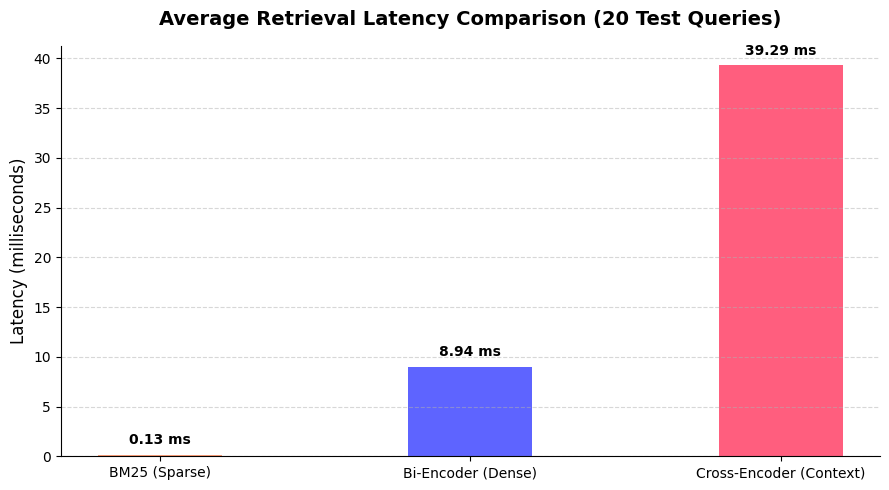

In [22]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# --- 1. ĐẢM BẢO TẤT CẢ CÁC MÔ HÌNH ĐÃ ĐƯỢC KHỞI TẠO ---
print("Checking and preparing retrieval models...")
if 'chunks' not in locals():
    raise NameError("Lỗi: Không tìm thấy biến 'chunks'. Hãy chạy Phase 1 trước.")
if 'eval_dataset' not in locals():
    raise NameError("Lỗi: Không tìm thấy biến 'eval_dataset'. Hãy chạy cell Load Dataset trước.")

# Khởi tạo mô hình Sparse BM25 (Phase 2) nếu chưa có
if 'bm25_index' not in locals():
    print("- Initializing Custom BM25 Index...")
    bm25_index = CustomBM25(chunks)

# Khởi tạo mô hình Dense Bi-Encoder (Phase 3) nếu chưa có
if 'dense_retriever' not in locals():
    dense_retriever = DenseRetriever("sentence-transformers/all-MiniLM-L6-v2")
    dense_retriever.index_corpus(chunks)

# Khởi tạo mô hình Context Cross-Encoder (Phase 4) nếu chưa có
if 'ce_model' not in locals():
    ce_model = initialize_cross_encoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

print("\nAll models ready. Starting comparative evaluation on 20 test cases...\n")


# --- 2. CHẠY THỬ NGHIỆM ĐÁNH GIÁ SONG SONG ---
comparison_data = []
latencies = {
    "BM25 (Sparse)": [],
    "Bi-Encoder (Dense)": [],
    "Cross-Encoder (Context)": []
}

# Duyệt qua từng câu hỏi trong bộ câu hỏi test
for q in eval_dataset:
    query_id = q['id']
    category = q['category']
    query_text = q['query']
    
    # A. Chạy truy vấn với mô hình Sparse (BM25)
    bm25_results, bm25_time = bm25_index.retrieve(query_text, chunks, top_k=1)
    bm25_best = bm25_results[0] if bm25_results else {"chunk_index": -1, "score": 0.0, "chunk_text": "N/A"}
    latencies["BM25 (Sparse)"].append(bm25_time)
    
    # B. Chạy truy vấn với mô hình Dense (Bi-Encoder)
    dense_results, dense_time = dense_retriever.retrieve(query_text, chunks, top_k=1)
    dense_best = dense_results[0] if dense_results else {"chunk_index": -1, "score": 0.0, "chunk_text": "N/A"}
    latencies["Bi-Encoder (Dense)"].append(dense_time)
    
    # C. Chạy truy vấn với mô hình Context (Cross-Encoder)
    ce_results, ce_time = single_stage_cross_encoder_retrieval(query_text, chunks, ce_model, top_k=1)
    ce_best = ce_results[0] if ce_results else {"chunk_index": -1, "score": 0.0, "chunk_text": "N/A"}
    latencies["Cross-Encoder (Context)"].append(ce_time)
    
    # Ghi nhận log so sánh chi tiết
    comparison_data.append({
        "ID": query_id,
        "Category": category,
        "Query": query_text,
        
        "BM25_Idx": bm25_best["chunk_index"],
        "BM25_Score": round(bm25_best["score"], 4),
        "BM25_Snippet": bm25_best["chunk_text"][:80] + "...",
        
        "Dense_Idx": dense_best["chunk_index"],
        "Dense_Score": round(dense_best["score"], 4),
        "Dense_Snippet": dense_best["chunk_text"][:80] + "...",
        
        "CE_Idx": ce_best["chunk_index"],
        "CE_Score": round(ce_best["score"], 4),
        "CE_Snippet": ce_best["chunk_text"][:80] + "..."
    })


# --- 3. HIỂN THỊ BẢNG SO SÁNH KẾT QUẢ ---
df_compare = pd.DataFrame(comparison_data)

# Tính toán và in ra thời gian phản hồi trung bình (đổi ra mili-giây)
avg_latencies = {model: (sum(times) / len(times)) * 1000 for model, times in latencies.items()}
print("\n" + "="*45)
print("     AVERAGE RETRIEVAL LATENCY (20 QUERIES)    ")
print("="*45)
for model, avg_t in avg_latencies.items():
    print(f"- {model:<25}: {avg_t:.2f} ms")
print("="*45)

# Định dạng hiển thị bảng kết quả so sánh (dùng gradient màu xanh để làm nổi bật điểm số)
display_cols = ["ID", "Category", "Query", "BM25_Idx", "BM25_Score", "Dense_Idx", "Dense_Score", "CE_Idx", "CE_Score"]
print("\n--- Model Retrieval Comparison Table ---")
styled_df = df_compare[display_cols].style.background_gradient(
    cmap="Blues", 
    subset=["BM25_Score", "Dense_Score", "CE_Score"]
)
display(styled_df)


# --- 4. VẼ BIỂU ĐỒ SO SÁNH THỜI GIAN TRUY VẤN (LATENCY) ---
plt.figure(figsize=(9, 5))

# Palette màu cao cấp: Cam nhạt (BM25), Tím-Xanh (Bi-Encoder), Hồng San Hô (Cross-Encoder)
colors = ['#FFA07A', '#5E64FF', '#FF5E7E']
bars = plt.bar(avg_latencies.keys(), avg_latencies.values(), color=colors, width=0.4)

# Trang trí biểu đồ chuyên nghiệp
plt.title("Average Retrieval Latency Comparison (20 Test Queries)", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Latency (milliseconds)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Ghi chú giá trị số cụ thể lên đỉnh mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0, 
        yval + (max(avg_latencies.values()) * 0.02), 
        f"{yval:.2f} ms", 
        ha='center', 
        va='bottom', 
        fontweight='bold',
        fontsize=10
    )

# Ẩn đường viền trên và phải
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
